# Inspect geometry-conditioned charge predictions for ten held-out molecules

Load the selected 20-epoch continuation checkpoint and compare **ten deterministic molecules from the held-out test split** using the supplied-geometry charge path. No latent-only sampling, training, Psi4, CCDC access, or W&B upload runs here.

**Reading the figures:** the original heavy-atom structure is shown twice with the reference RESP charges and the model charges colored separately. The model receives the original atom types and coordinates, but not the reference charges. Original bonds are drawn for context.

**Charge caveat:** these are Psi4/RESP labels that passed the repository's provenance, convergence, charge-sum, and ±2 e trust gates. That gate is a model-compatibility filter, not proof of chemical accuracy. The charge head is bounded to ±2 e. All charges below absorb each hydrogen's charge into its bonded heavy atom.

Use the `.pixi/envs/ml-gpu/bin/python` kernel (or the CPU ML kernel). Set `DEVICE = "cpu"` to force CPU. Run from the repository or its `notebooks/` directory.

In [1]:
from pathlib import Path
import sys, json, copy, os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/ccdc-notebook-matplotlib")
ROOT = Path.cwd().resolve()
if not (ROOT / "MolFLAE").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "MolFLAE").is_dir(), "Run from the repository or notebooks directory"
sys.path.insert(0, str(ROOT / "scripts"))
RUN = ROOT / "runs/trusted-split80-20-differential-lr-20epoch"
CHECKPOINT = RUN / "best-test.ckpt"
TEST = ROOT / "runs/csd-small-v1-trusted-v3-split80-20/test"
DEVICE = "auto"  # auto, cpu, cuda, cuda:N
N_MOLECULES = 10
# Change these IDs explicitly to inspect other test molecules.
run_info = json.loads((RUN / "run.json").read_text())
MOLECULE_IDS = run_info["test_ids"][:N_MOLECULES]
print("Fixed test IDs:", MOLECULE_IDS)


Fixed test IDs: ['ABUMIT', 'ACEMID11', 'ADUQOF', 'AMBNAC17', 'AMIPYR01', 'AMOREA', 'ASAJOX', 'BEDMON', 'BIDJIH', 'BIYMOP']


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from rdkit import Chem
from torch_geometric.loader import DataLoader
from _workflow.data import structures, load_labels, digest
from _workflow.training import molecular_data, load_pretrained, resolve_device, charge_predictions
from _workflow.metrics import inputs

assert CHECKPOINT.is_file(), f"Missing checkpoint: {CHECKPOINT}"
assert len(MOLECULE_IDS) == len(set(MOLECULE_IDS))
assert set(MOLECULE_IDS) <= set(run_info["test_ids"])
all_records = {r[0]: r for r in structures(TEST / "sdf")}
records = [all_records[i] for i in MOLECULE_IDS]
labels, verified = load_labels(TEST / "charges/charges.npz", records)
assert verified, "Require source-verified labels"
for identifier, source, _ in records:
    assert digest(source) == run_info["test_source_sha256"][identifier]
config = copy.deepcopy(json.loads((RUN / "config.json").read_text()))
device = resolve_device(DEVICE, config)
torch.set_num_threads(2)
model, loaded = load_pretrained(config, CHECKPOINT, device)
assert not loaded["new_charge_head"], "Expected a trained charge head"
model.eval()
model.external_logging = True
data = molecular_data(records, labels)
print(f"Loaded {CHECKPOINT.name} on {device}; {len(data)} held-out molecules")


/home/vlad/code/ccdc/.pixi/envs/ml-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Encoder params: 2.96M
KL layer params: 0.01M
Decoder params: 2.84M
Of which 16641 are charge head params.
total params: 5.81M



Loaded best-test.ckpt on cuda:0; 10 held-out molecules


## Predict charges from supplied geometry

This path uses the original heavy-atom coordinates and atom types as decoder inputs. It does not sample a new structure, and it does not receive the reference charges. The result isolates the charge head from structural-generation errors.

In [3]:
results = []
loader = DataLoader(data, batch_size=len(data), shuffle=False)
with torch.no_grad():
    batch = next(iter(loader)).to(device)
    x, _, _ = inputs(model, batch)
    geometry_q = charge_predictions(model, batch)
    for i, (identifier, _, mol) in enumerate(records):
        mask = batch.batch == i
        reference = x[mask].cpu().numpy()
        reference_q = batch.charges[mask].flatten().cpu().numpy()
        predicted_q = geometry_q[mask].flatten().cpu().numpy()
        atomic_numbers = np.array([6, 7, 8, 9, 15, 16, 17, 35, 53])
        reference_z = batch.h[mask].flatten().cpu().numpy()
        heavy = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() != 1]
        mapping = {original: local for local, original in enumerate(heavy)}
        bonds = [(mapping[bond.GetBeginAtomIdx()], mapping[bond.GetEndAtomIdx()])
                 for bond in mol.GetBonds()
                 if bond.GetBeginAtomIdx() in mapping and bond.GetEndAtomIdx() in mapping]
        item = dict(identifier=identifier, reference=reference,
                    reference_z=reference_z, reference_q=reference_q,
                    geometry_q=predicted_q, bonds=bonds, source_atom_indices=heavy)
        for key in ("reference", "reference_q", "geometry_q"):
            assert np.isfinite(item[key]).all(), key
        error = predicted_q - reference_q
        item["geometry_charge_mae_e"] = float(np.mean(np.abs(error)))
        item["geometry_charge_rmse_e"] = float(np.sqrt(np.mean(error ** 2)))
        results.append(item)

print("ID           geometry charge MAE (e)   geometry charge RMSE (e)")
for r in results:
    print(f"{r['identifier']:12s} {r['geometry_charge_mae_e']:22.3f} {r['geometry_charge_rmse_e']:25.3f}")


ID           geometry charge MAE (e)   geometry charge RMSE (e)
ABUMIT                        0.009                     0.011
ACEMID11                      0.022                     0.024
ADUQOF                        0.027                     0.030
AMBNAC17                      0.036                     0.050
AMIPYR01                      0.037                     0.046
AMOREA                        0.264                     0.303
ASAJOX                        0.037                     0.043
BEDMON                        0.023                     0.030
BIDJIH                        0.076                     0.112
BIYMOP                        0.028                     0.039


## Supplied-geometry charge comparisons

The left panels show the same original structure colored by reference and predicted charges. The charge plot compares the reference RESP labels with the supplied-geometry prediction. The zoomed panel emphasizes the model range; the full-range panel keeps every reference value visible.

The loop writes one figure per held-out molecule plus `predictions.json` to a fresh ignored `runs/reconstruction-inspection-*` directory. Set `CHARGE_YLIM = (-0.3, 0.3)` for an explicit zoom range, or leave it as `None` for automatic scaling per molecule. Change `ELEVATION` and `AZIMUTH` to adjust the static 3D views.

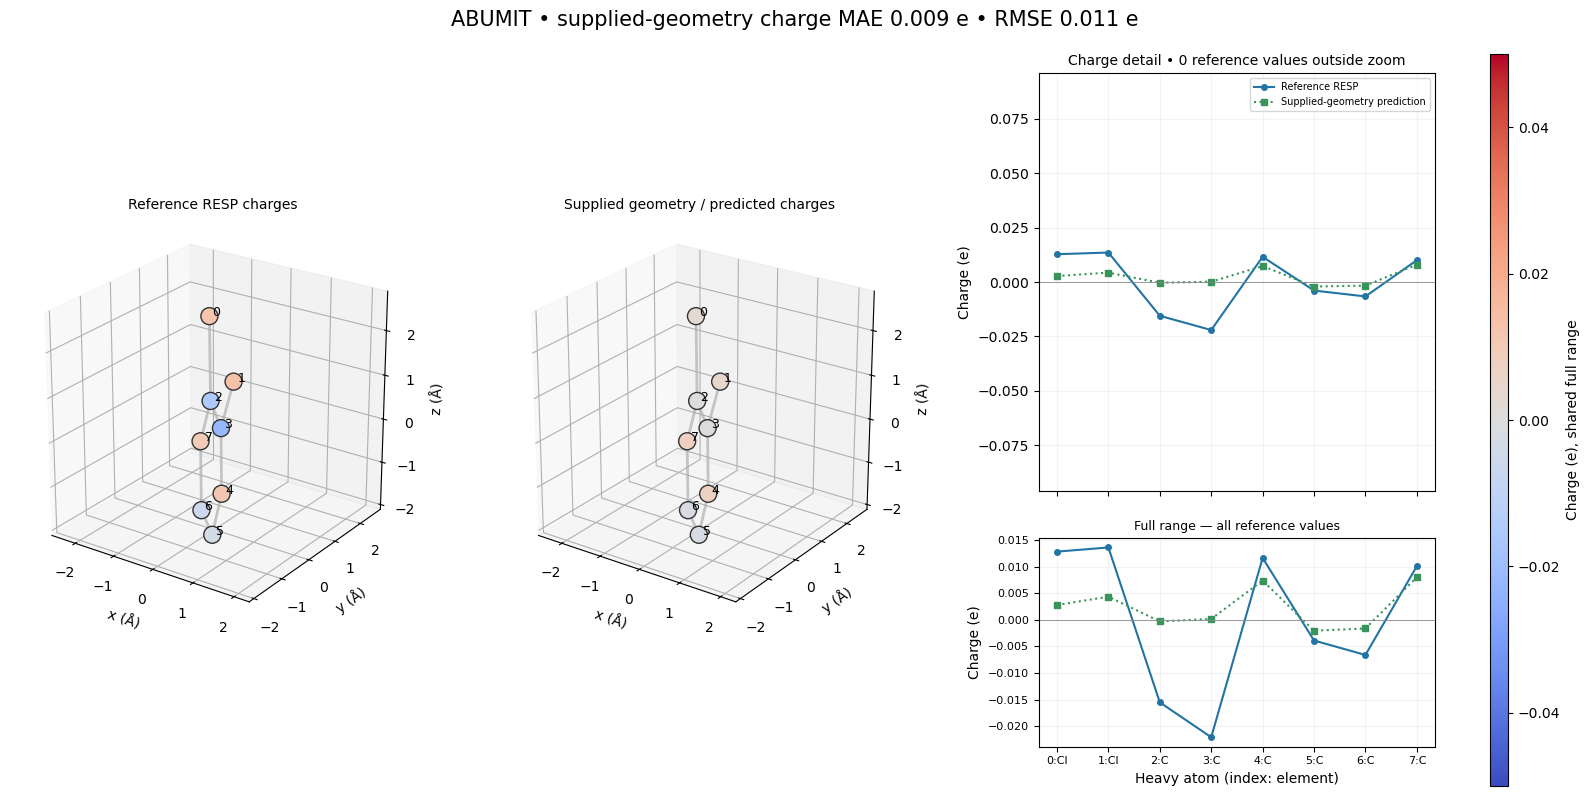

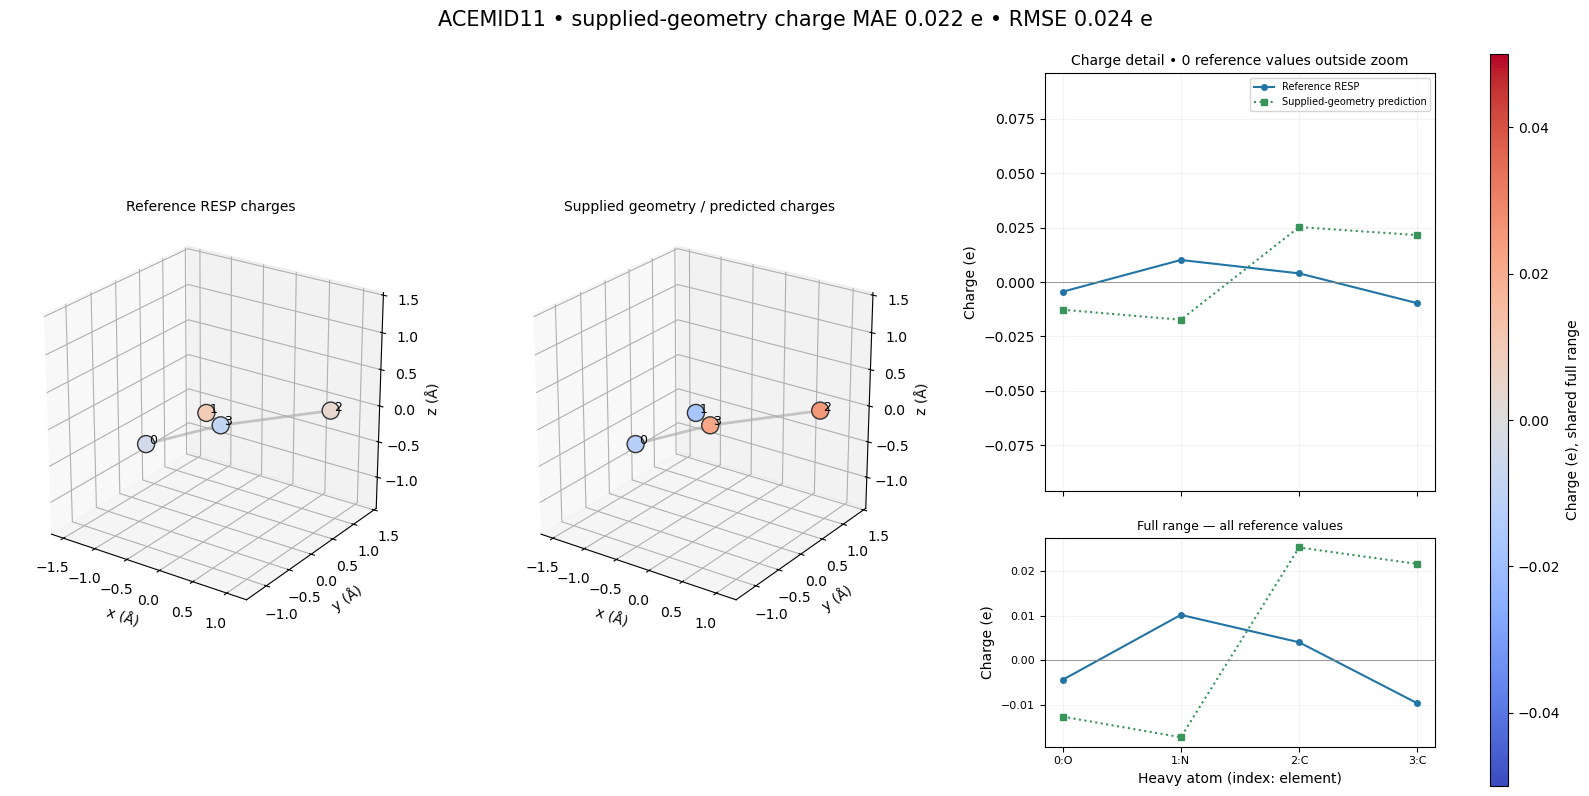

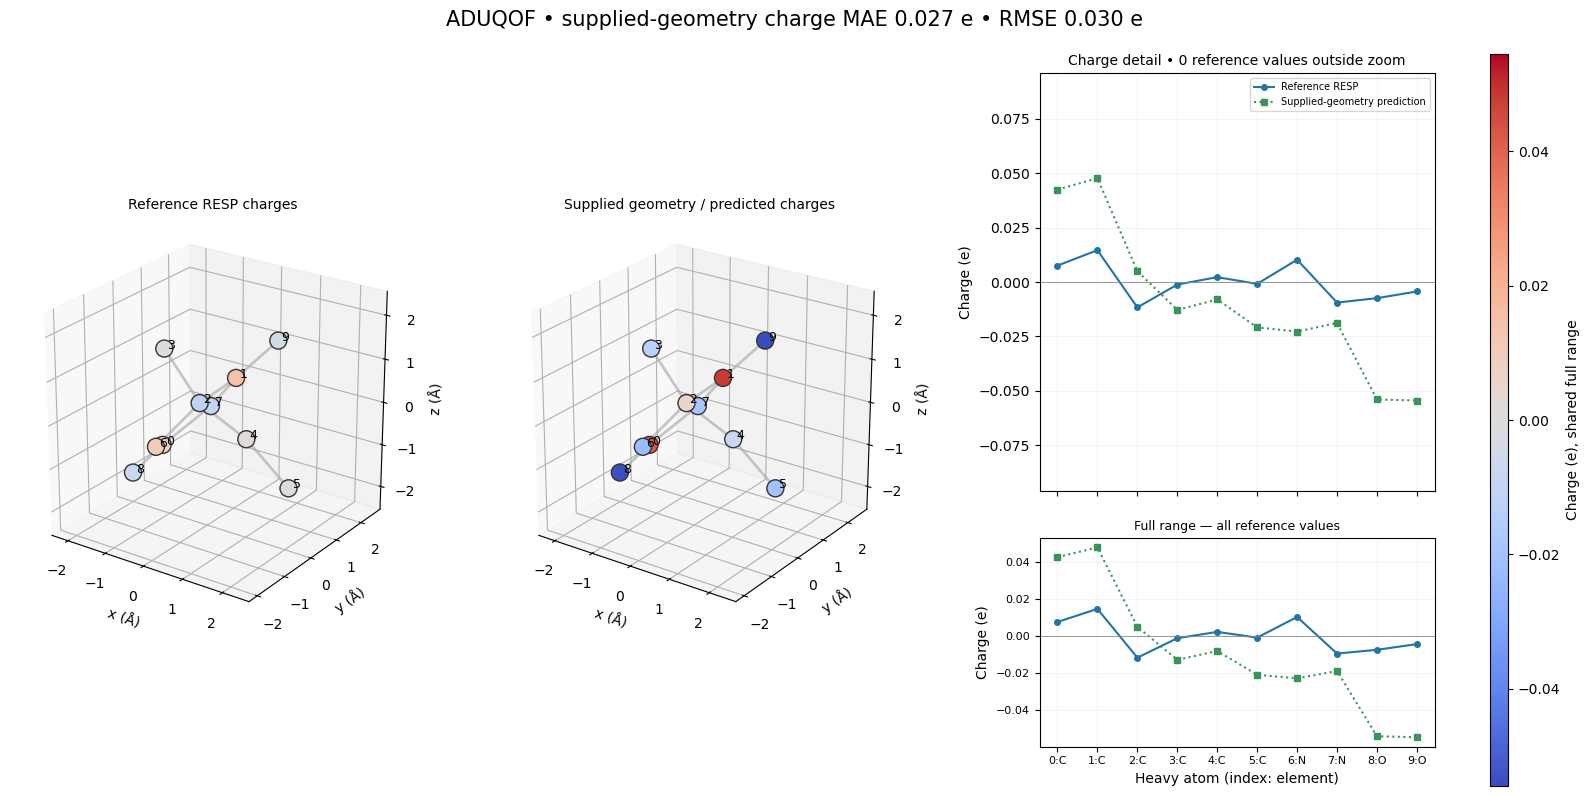

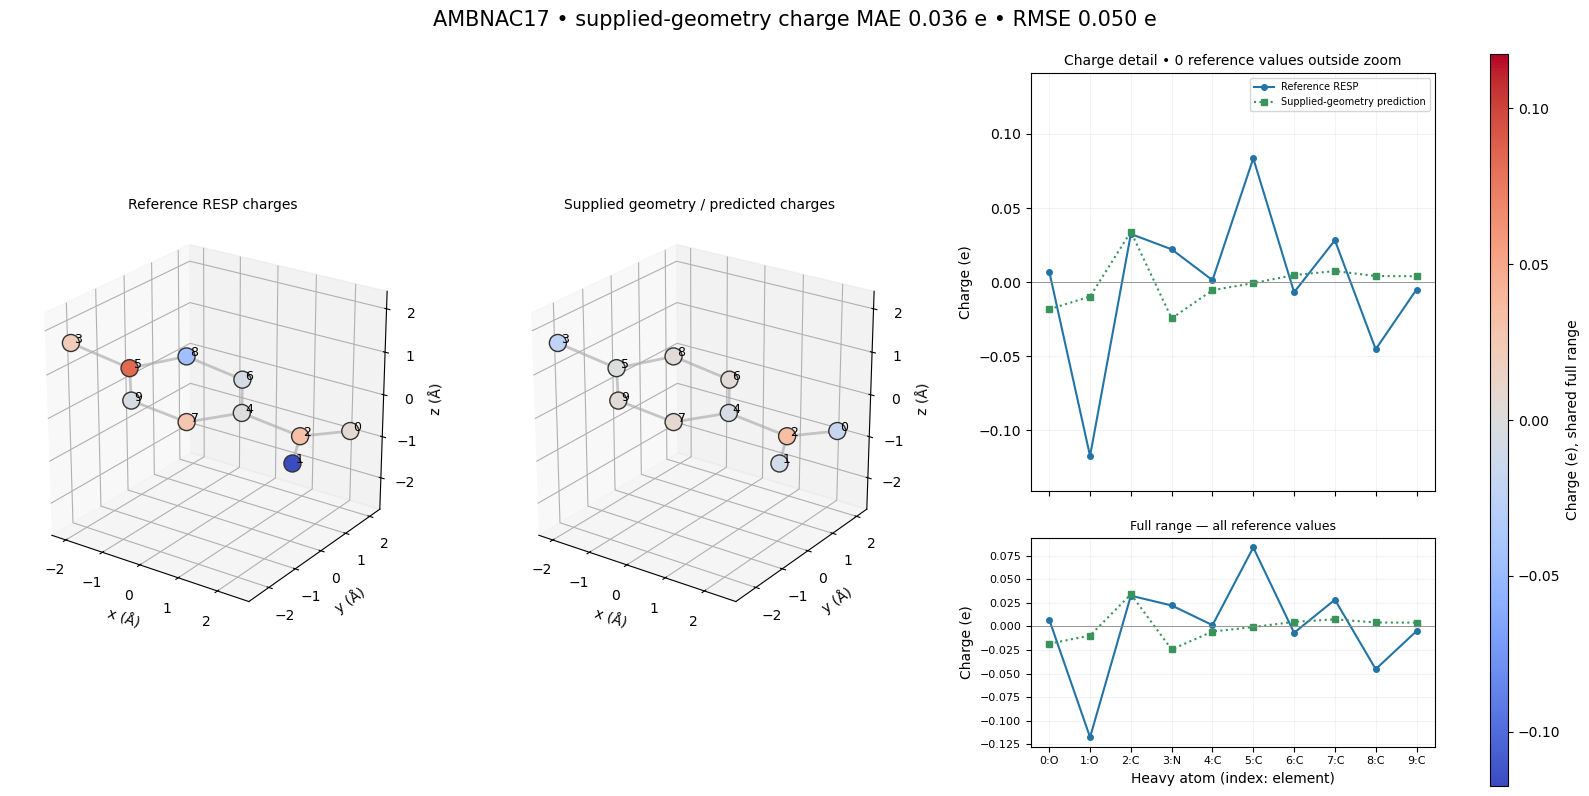

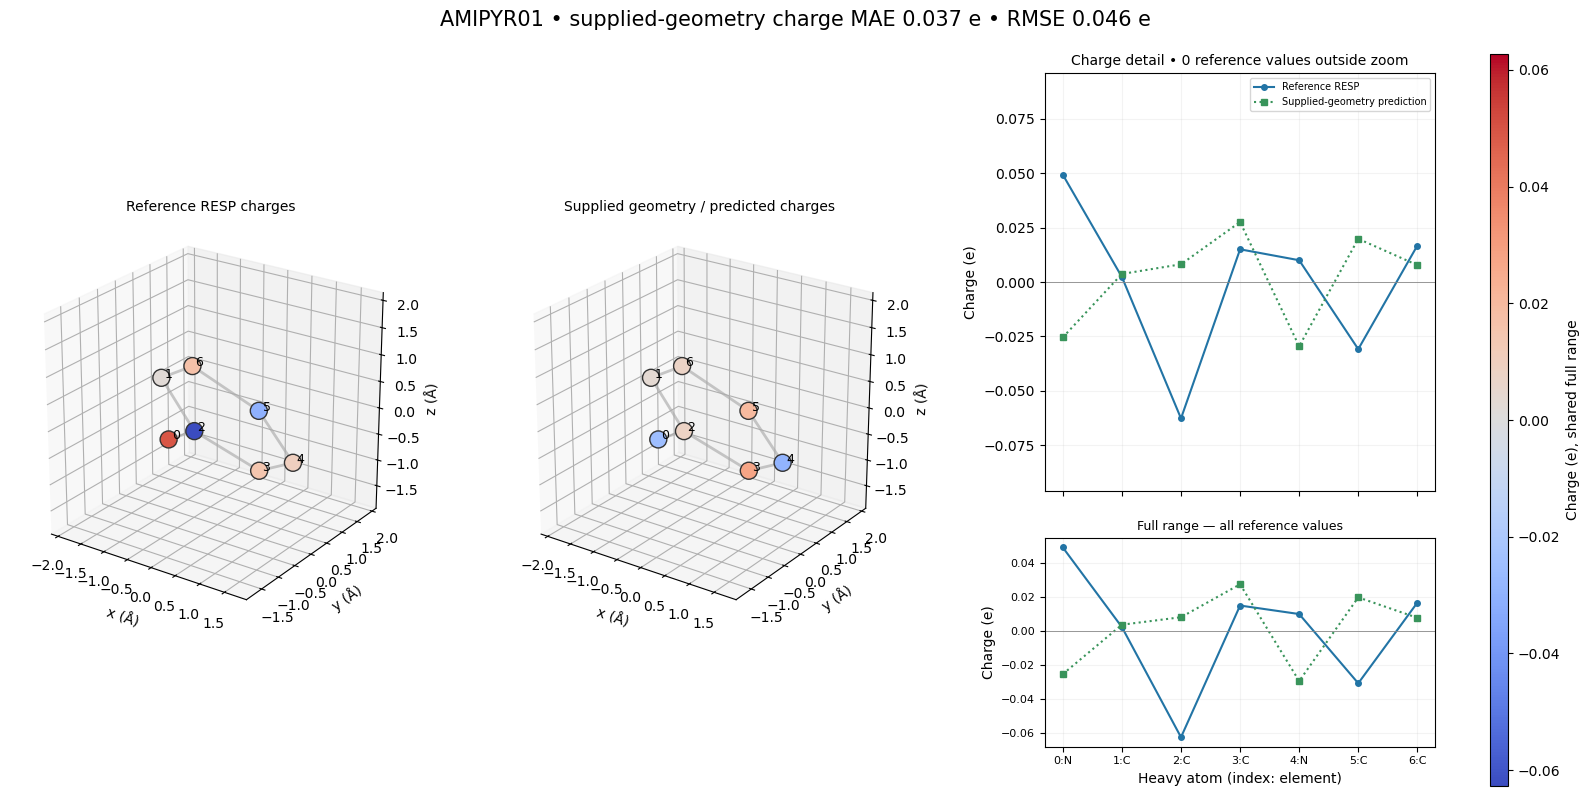

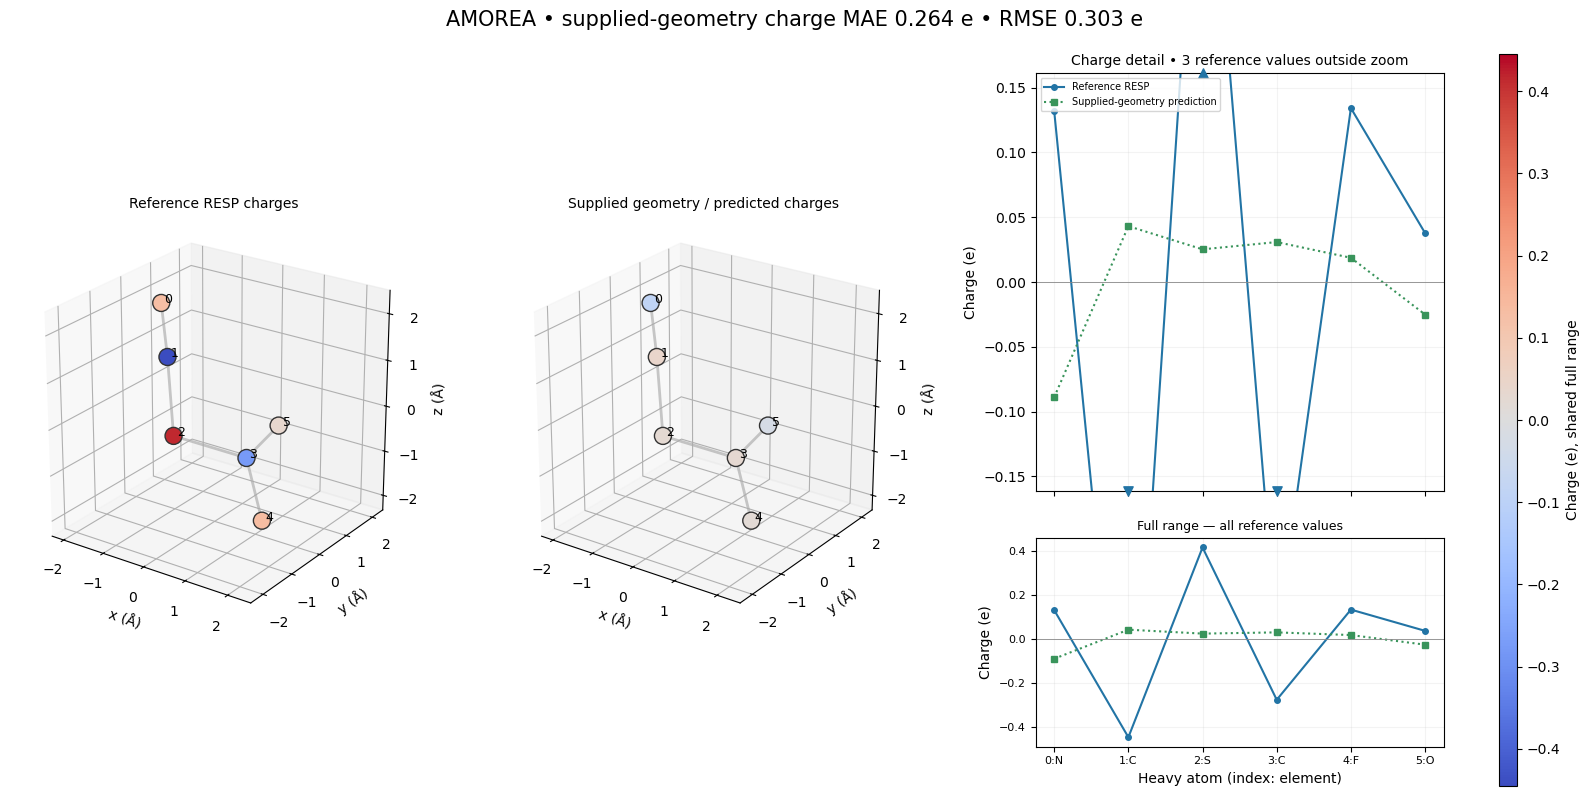

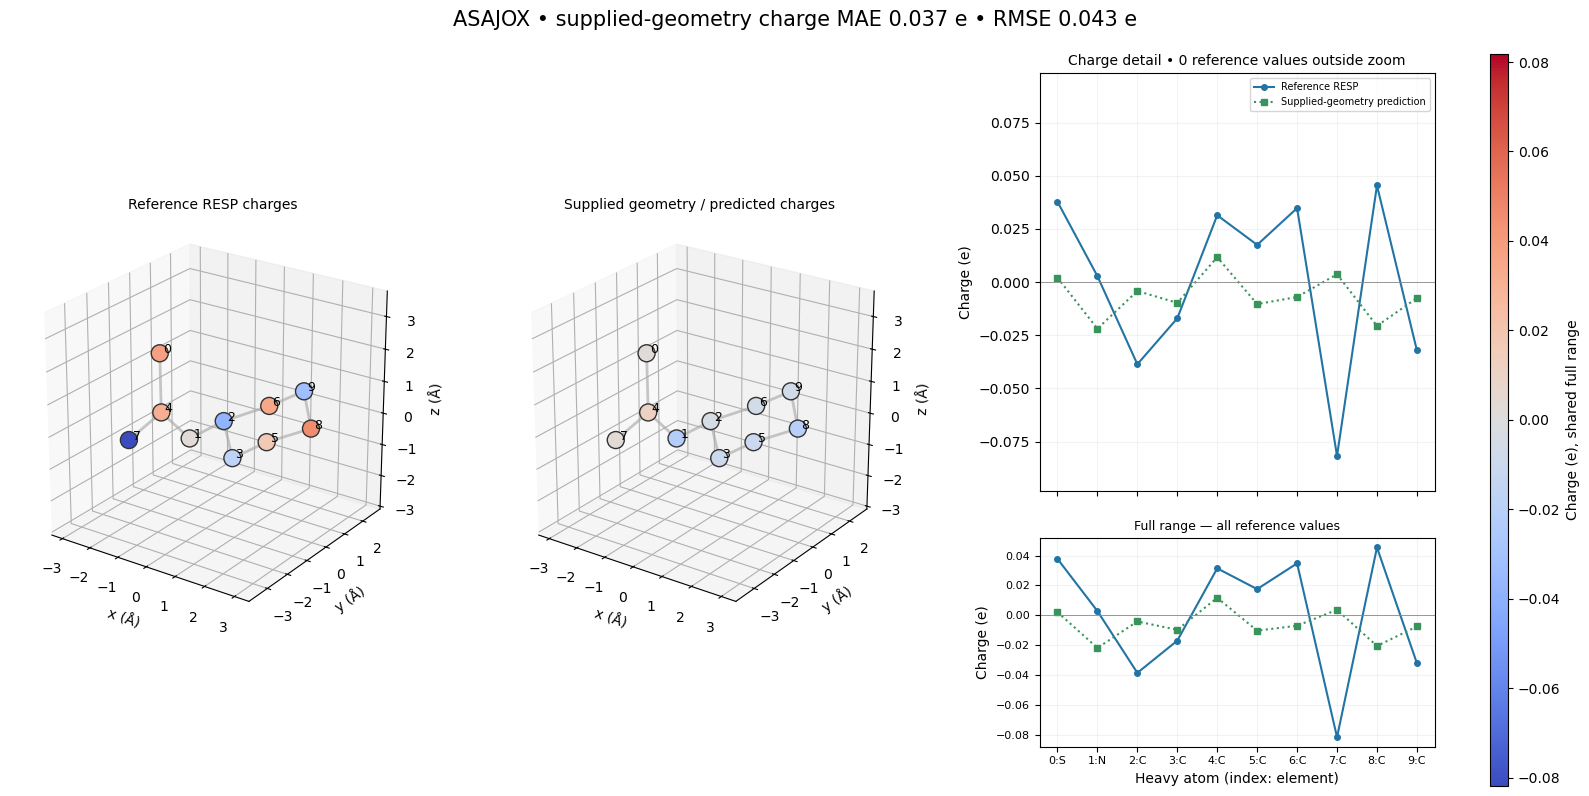

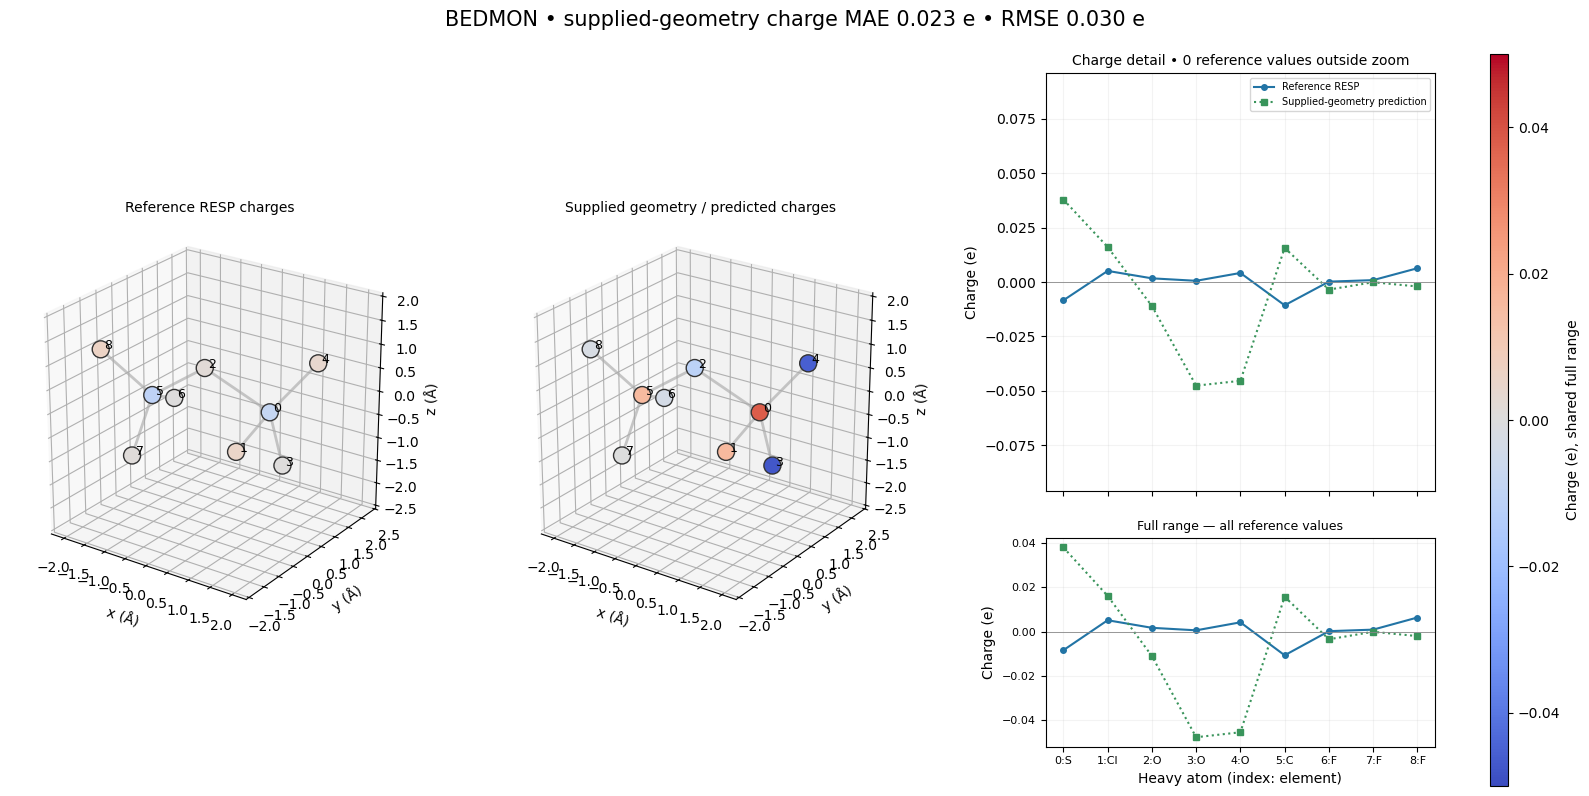

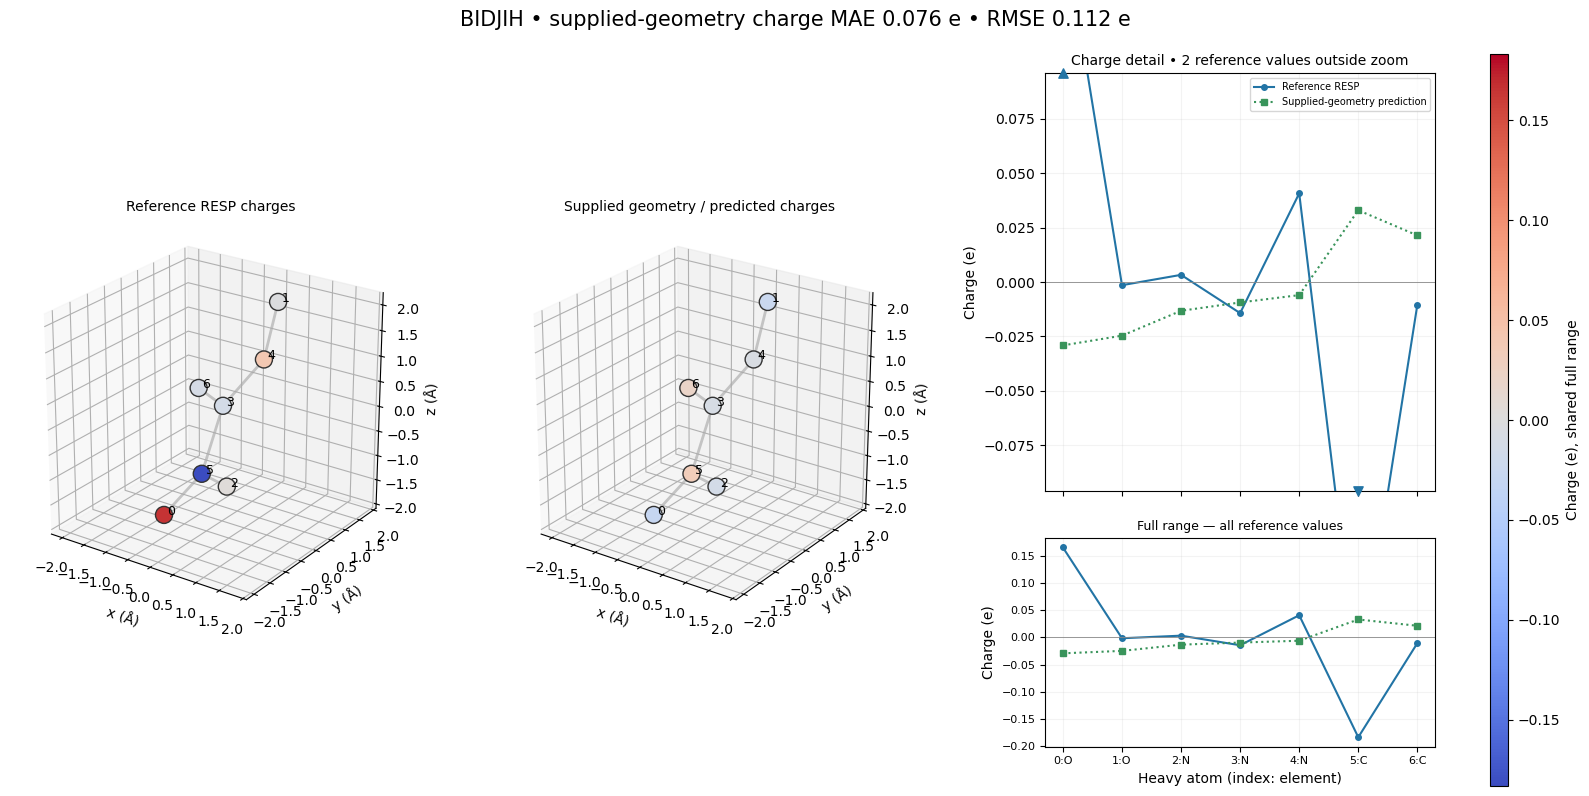

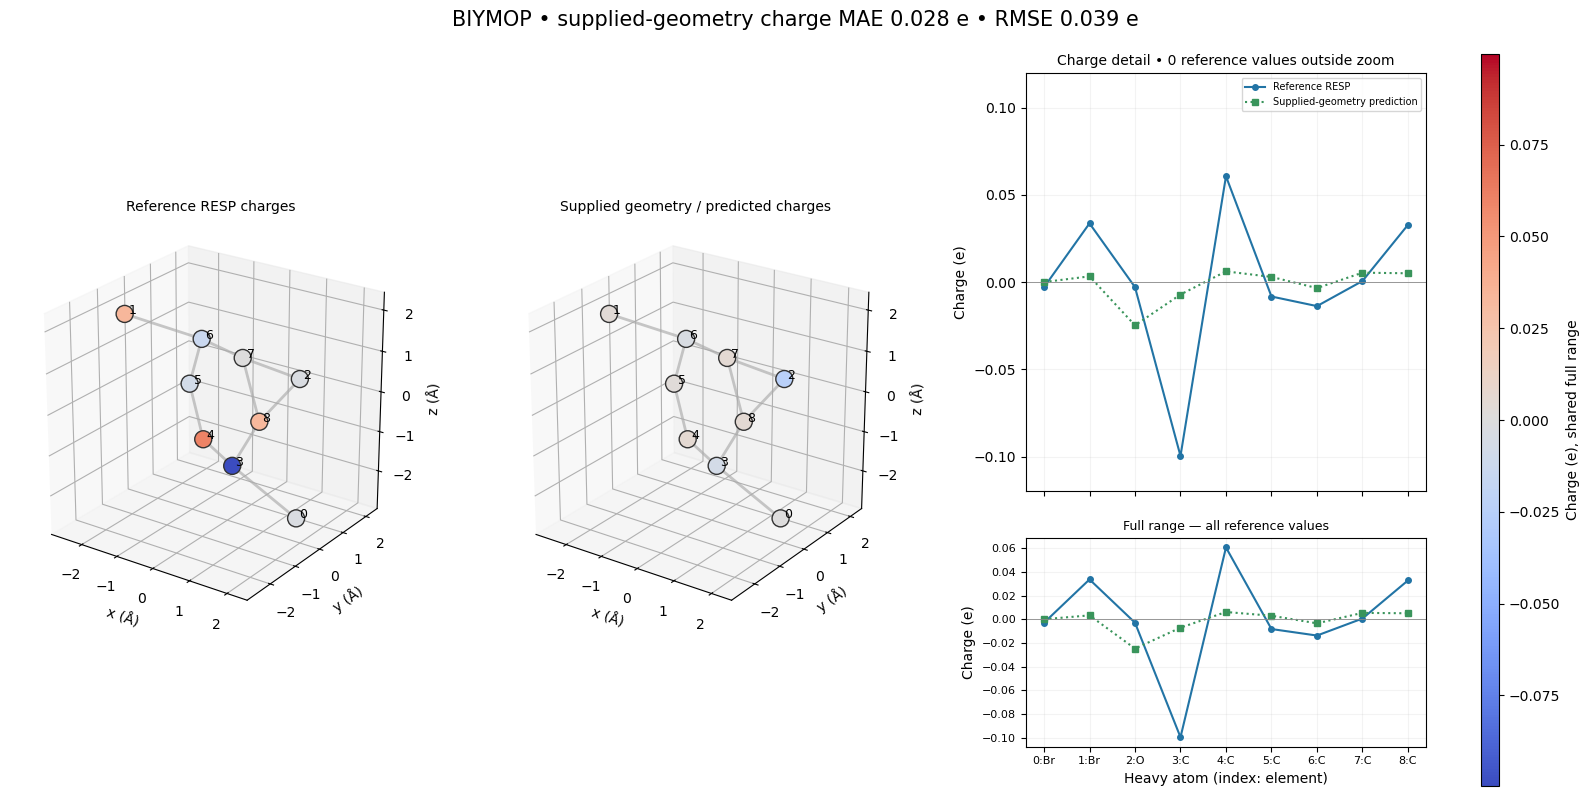

Saved figures and matched numerical predictions to /home/vlad/code/ccdc/runs/reconstruction-inspection-20260915T115533285353Z


In [4]:
from datetime import datetime, timezone
OUTPUT = ROOT / "runs" / ("reconstruction-inspection-" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ"))
OUTPUT.mkdir(parents=True, exist_ok=False)
ELEVATION, AZIMUTH = 24, -55
CHARGE_YLIM = None  # Optional fixed zoom, e.g. (-0.3, 0.3)
BLUE, GREEN = "#2274A5", "#39945B"
periodic = Chem.GetPeriodicTable()

def setup_3d(ax, r):
    coords = r["reference"]
    midpoint = (coords.max(0) + coords.min(0)) / 2
    radius = max(float(np.ptp(coords, axis=0).max()) / 2, 0.5) + 0.35
    ax.set(xlim=(midpoint[0]-radius, midpoint[0]+radius),
           ylim=(midpoint[1]-radius, midpoint[1]+radius),
           zlim=(midpoint[2]-radius, midpoint[2]+radius),
           xlabel="x (Å)", ylabel="y (Å)", zlabel="z (Å)")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(ELEVATION, AZIMUTH)

def original_bonds(ax, r, color):
    for a, b in r["bonds"]:
        ax.plot(*r["reference"][[a, b]].T, color=color, linewidth=2, alpha=0.65)

for r in results:
    fig = plt.figure(figsize=(16, 8), layout="constrained")
    fig.get_layout_engine().set(w_pad=0.15, h_pad=0.12, wspace=0.20)
    grid = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.25, 0.045])
    reference_ax = fig.add_subplot(grid[0, 0], projection="3d")
    prediction_ax = fig.add_subplot(grid[0, 1], projection="3d")
    charge_grid = grid[0, 2].subgridspec(2, 1, height_ratios=[2, 1])
    charge_ax = fig.add_subplot(charge_grid[0])
    full_ax = fig.add_subplot(charge_grid[1], sharex=charge_ax)
    fig.suptitle(f"{r['identifier']} • supplied-geometry charge MAE {r['geometry_charge_mae_e']:.3f} e • RMSE {r['geometry_charge_rmse_e']:.3f} e", fontsize=15)
    limit = max(float(np.abs(np.r_[r["reference_q"], r["geometry_q"]]).max()), 0.05)
    norm = Normalize(-limit, limit)
    for ax, q, title in [(reference_ax, r["reference_q"], "Reference RESP charges"),
                         (prediction_ax, r["geometry_q"], "Supplied geometry / predicted charges")]:
        original_bonds(ax, r, "#aaaaaa")
        ax.scatter(*r["reference"].T, c=q, cmap="coolwarm", norm=norm, s=150,
                   edgecolors="#333333", depthshade=False)
        for i, point in enumerate(r["reference"]): ax.text(*point, f" {i}", fontsize=9)
        ax.set_title(title, fontsize=10)
        setup_3d(ax, r)
    fig.colorbar(ScalarMappable(norm=norm, cmap="coolwarm"), cax=fig.add_subplot(grid[0, 3]),
                 label="Charge (e), shared full range")
    atom_ids = np.arange(len(r["reference_q"]))
    prediction_extent = max(float(np.abs(r["geometry_q"]).max()), 0.08)
    nearby_reference = r["reference_q"][np.abs(r["reference_q"]) <= 2 * prediction_extent]
    zoom_extent = max(prediction_extent, float(np.abs(nearby_reference).max()) if len(nearby_reference) else 0) * 1.2
    low, high = CHARGE_YLIM if CHARGE_YLIM is not None else (-zoom_extent, zoom_extent)
    if not np.isfinite([low, high]).all() or low >= high:
        raise ValueError("CHARGE_YLIM must contain two finite increasing values")
    for ax in (charge_ax, full_ax):
        ax.plot(atom_ids, r["reference_q"], "o-", color=BLUE, label="Reference RESP", markersize=4)
        ax.plot(atom_ids, r["geometry_q"], "s:", color=GREEN, label="Supplied-geometry prediction", markersize=4)
        ax.axhline(0, color="#888888", linewidth=0.6)
        ax.set_ylabel("Charge (e)")
        ax.grid(alpha=0.15)
    charge_ax.set_ylim(low, high)
    outside = (r["reference_q"] < low) | (r["reference_q"] > high)
    for mask, boundary, marker in [(r["reference_q"] > high, high, "^"), (r["reference_q"] < low, low, "v")]:
        charge_ax.scatter(atom_ids[mask], np.full(mask.sum(), boundary), color=BLUE, marker=marker, s=45, clip_on=False, zorder=5)
    charge_ax.set_title(f"Charge detail • {outside.sum()} reference values outside zoom", fontsize=10)
    charge_ax.legend(fontsize=7, loc="best")
    charge_ax.tick_params(labelbottom=False)
    full_ax.set(xticks=atom_ids, xticklabels=[f"{i}:{periodic.GetElementSymbol(int(z))}" for i,z in enumerate(r["reference_z"])],
                xlabel="Heavy atom (index: element)", title="Full range — all reference values")
    full_ax.title.set_fontsize(9)
    full_ax.tick_params(labelsize=8)
    fig.savefig(OUTPUT / f"{r['identifier']}.png", dpi=130)
    plt.show()
    plt.close(fig)

serializable = [{k: v.tolist() if isinstance(v, np.ndarray) else v for k,v in r.items()} for r in results]
(OUTPUT / "predictions.json").write_text(json.dumps({"checkpoint":str(CHECKPOINT), "checkpoint_sha256":digest(CHECKPOINT),
    "device":str(device), "molecules":serializable}, indent=2) + "\n")
print("Saved figures and matched numerical predictions to", OUTPUT)
